# Setup python environment

In [1]:
%pip install pandas numpy matplotlib tensorflow scikit-learn ai_edge_litert

Note: you may need to restart the kernel to use updated packages.


In [204]:
import numpy as np
import tensorflow as tf
import random
import os

# Set the seed for reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


# Constants

In [305]:
FEATURE_COLS = ["temperature", "pressure", "humidity", "gas_resistance"]
# FEATURE_COLS = ["humidity", "gas_resistance"]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "label"
SEQ_LEN = 10
# SENSORS = [3, 4, 7, 8]
SENSORS = [3]
# SENSORS = [1, 2, 5, 6]

CLASSES = [
    "lavender",
    "grapefruit",
    "eucalyptus",
    "air"
]
NUM_CLASSES = len(CLASSES)

TO_BE_CORRECTED = [
    "lavender",
    "grapefruit",
    "eucalyptus"
]

SAMPLE_TYPES = ["sample", "baseline"]
DATA_PATH = "../data/dataset/oils"

SAVE_PATH = "../models/cnn/"
MODEL_NAME = "background_pca_3"

# Load Data

In [306]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure correct order
    df = df.sort_values(["id", "position"])
    
    for col in feature_cols:
        df[col + "_diff"] = df.groupby("id")[col].diff()
    
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str, sample_types: list) -> pd.DataFrame:
    dfs = []
    i = 0
    for folder in os.listdir(base_dir):
        if folder not in CLASSES:
            continue

        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue

            has_desired_type = False
            for st in sample_types:
                if st in os.path.basename(file):
                    has_desired_type = True
                    break
            if not has_desired_type: continue


            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            df['id'] = df.apply(lambda x: f"{i}_{x['sensor_index']}_{x['fingerprint_index']}", axis=1)
            i += 1
            dfs.append(df)

    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)

data = load_dataset(DATA_PATH, SAMPLE_TYPES)
data = add_fotd_features(data, FEATURE_COLS)
data = data[data["sensor_index"].isin(SENSORS)]
print(len(data["id"].unique()), " fingerprints loaded.")
data

216  fingerprints loaded.


,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,temperature_diff,pressure_diff,humidity_diff,gas_resistance_diff
8,3,0,1,100,150,27.65,1035.13,49.25,164208,eucalyptus_baseline,0_3_0,0.00,0.00,0.00,0.0
14,3,0,2,100,150,27.71,1035.14,49.17,174983,eucalyptus_baseline,0_3_0,0.06,0.01,-0.08,10775.0
23,3,0,3,100,150,27.76,1035.14,49.06,178833,eucalyptus_baseline,0_3_0,0.05,0.00,-0.11,3850.0
36,3,0,4,200,150,27.80,1035.14,49.01,32537,eucalyptus_baseline,0_3_0,0.04,0.00,-0.05,-146296.0
45,3,0,5,200,150,27.85,1035.15,48.98,33482,eucalyptus_baseline,0_3_0,0.05,0.01,-0.03,945.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18038,3,9,5,200,150,30.49,1034.54,48.68,70388,lavender,5_3_9,0.00,0.00,-0.20,-7732.0
18048,3,9,6,200,150,30.50,1034.54,48.99,65123,lavender,5_3_9,0.01,0.00,0.31,-5265.0
18057,3,9,7,320,150,30.51,1034.54,48.69,28194,lavender,5_3_9,0.01,0.00,-0.30,-36929.0
18068,3,9,8,320,150,30.54,1034.56,48.75,34124,lavender,5_3_9,0.03,0.02,0.06,5930.0


### Drop Outliers

In [307]:
SIGMA_TOLERANCE = 1
for s in SENSORS:
    df = data[data["sensor_index"] == s]
    for feat in FEATURE_COLS_EXTENDED:
        for step in range(SEQ_LEN):
            df = df[df["position"] == step]
            mean = df[feat].mean()
            std = df[feat].std()
            data = data.drop(df[(df[feat] - mean) > SIGMA_TOLERANCE * std].index)
print(f"Dropped rows with deviation >= {SIGMA_TOLERANCE}sigma")
print(len(data), " rows left.")

Dropped rows with deviation >= 1sigma
2083  rows left.


### Drop incomplete fingerprints

In [308]:
complete_ids = []
grouped = data.groupby("id")
for group in grouped:
    seq_len = len(group[1])
    if seq_len == SEQ_LEN:
        complete_ids.append(group[0])

data = data[data["id"].isin(complete_ids)]
print("Number of complete fingerprints per class: ")
for cls in CLASSES:
    print(
        f"{cls+' '*(max(map(len, CLASSES)) - len(cls))}\t{len(data[data[TARGET_COL] == cls]["id"].unique())}"
    )

Number of complete fingerprints per class: 
lavender  	21
grapefruit	16
eucalyptus	26
air       	0


### Baseline Correction

In [309]:
def fractional_baseline_correction(df: pd.DataFrame, feature_names: list, baseline: pd.Series, epsilon: float = 1e-6) -> pd.DataFrame:
    for feat in feature_names:
        df[feat] = df[feat].apply(lambda x: (x - baseline[feat]) / (baseline[feat] + epsilon))
    return df

data_corrected = data.copy()
dfs = []
baseline_dfs = []
for s in SENSORS:
    sensor_df = data_corrected[data_corrected["sensor_index"] == s]
    for t in range(SEQ_LEN):
        for cls in TO_BE_CORRECTED:
            baseline_label = cls + "_baseline"
            baseline_df = sensor_df[sensor_df["position"] == t]
            baseline_df = baseline_df[baseline_df[TARGET_COL] == baseline_label]
            baseline = baseline_df[FEATURE_COLS_EXTENDED].mean()
            baseline_dfs.append(fractional_baseline_correction(baseline_df, FEATURE_COLS_EXTENDED, baseline))
            df = data_corrected[data_corrected["sensor_index"] == s]
            df = df[df["position"] == t]
            df = df[df[TARGET_COL] == cls]
            df = fractional_baseline_correction(df, FEATURE_COLS_EXTENDED, baseline)
            dfs.append(df)
print("Number of subsets corrected: ", len(dfs))
data_corrected = pd.concat(dfs)
baseline_dfs = pd.concat(baseline_dfs)
baseline_dfs[TARGET_COL] = "air"
print("Label of baseline recordings set to air.")

data_corrected = pd.concat([data_corrected.copy(), baseline_dfs.copy()])
print(f"Working with {len(data_corrected.groupby("id"))} corrected fingerprints.")

Number of subsets corrected:  30
Label of baseline recordings set to air.
Working with 107 corrected fingerprints.


## Split Data

This has to happen at this stage to prevent data leakage.

For the final version that gets exported, use all the available data, but we need train-test split for in-place evaluation.

In [310]:
TEST_RATIO = 0.0
train_data_ids = np.random.choice(complete_ids, size=int(len(complete_ids)*(1 - TEST_RATIO)), replace=False)
train_data = data_corrected[data_corrected["id"].isin(train_data_ids)]
test_data = data_corrected[data_corrected["id"].isin([i for i in complete_ids if i not in train_data_ids])]

print("Number of training fingerprints: ",len(train_data["id"].unique()))
print("Number of testing fingerprints: ", len(test_data["id"].unique()))

Number of training fingerprints:  107
Number of testing fingerprints:  0


### Standard Scaling (needed for PCA)

We do stepwise and sensorwise scaling.

In [311]:
from sklearn.preprocessing import StandardScaler

dfs = []
for s in SENSORS:
    for step in range(SEQ_LEN):
        df = train_data[train_data["sensor_index"] == s]
        df = df[df["position"] == step]
        scaler = StandardScaler()
        df[FEATURE_COLS_EXTENDED] = scaler.fit_transform(df[FEATURE_COLS_EXTENDED])
        dfs.append(df)
        print(f"Sensor {s} - Step {step} - mean: {scaler.mean_} - var: {scaler.var_}")
train_data_scaled = pd.concat(dfs)

Sensor 3 - Step 0 - mean: [ 1.20541253e-02  1.58023221e-04  3.59164965e-02 -1.88629804e-01
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00] - var: [4.74635862e-04 4.88493279e-08 1.88764149e-03 8.15569517e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Sensor 3 - Step 1 - mean: [ 1.20307741e-02  1.58532344e-04  3.61057079e-02 -2.75684453e-01
 -4.36077420e-03 -6.83271147e-01 -2.03919381e-01 -2.77054775e-01] - var: [4.61449494e-04 4.87633832e-08 1.89291699e-03 1.70268185e-01
 1.82968248e-01 1.42260417e+01 2.99504065e+00 1.72212001e-01]
Sensor 3 - Step 2 - mean: [ 1.20663034e-02  1.60515643e-04  3.63096997e-02 -2.54774364e-01
 -3.73623667e-02 -8.66429084e-01 -1.30210227e-01 -3.15787464e-01] - var: [4.48548904e-04 4.97306653e-08 1.93020886e-03 1.84553643e-01
 6.29820840e-01 1.00342339e+01 5.17417291e+00 1.55653021e-01]
Sensor 3 - Step 3 - mean: [ 1.20991606e-02  1.61040185e-04  3.65868122e-02 -2.38463325e-01
 -1.95121609e-02 -2.80735544e+02 -7.83056513e-01

In [312]:
train_data_scaled

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,temperature_diff,pressure_diff,humidity_diff,gas_resistance_diff
17207,3,1,0,320,150,-2.007574,-0.408818,2.343728,-2.158234,lavender,5_3_1,0.000000,0.000000,0.000000,0.000000
18087,3,10,0,320,150,-0.098831,-0.365081,1.419971,-1.006317,lavender,5_3_10,0.000000,0.000000,0.000000,0.000000
18187,3,11,0,320,150,-0.023087,-0.321344,1.440730,-1.037380,lavender,5_3_11,0.000000,0.000000,0.000000,0.000000
18283,3,12,0,320,150,0.052657,-0.365081,1.425161,-1.070645,lavender,5_3_12,0.000000,0.000000,0.000000,0.000000
18379,3,13,0,320,150,0.128401,-0.233870,1.430350,-1.082018,lavender,5_3_13,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,3,2,9,320,150,-2.133454,-0.783049,0.074053,-0.977636,air,0_3_2,0.790148,-0.117450,-0.133975,0.070949
2019,3,20,9,320,150,0.139064,-0.658777,-1.320220,1.406350,air,0_3_20,-0.531864,-0.117450,0.086809,1.154079
2120,3,21,9,320,150,0.207929,-0.658777,-1.335712,1.433848,air,0_3_21,-0.531864,-0.117450,-0.133975,1.147238
2605,3,26,9,320,150,0.535033,-0.575929,-1.511287,1.597258,air,0_3_26,-0.531864,0.636854,-0.007813,1.504101


# Neural Network

## Data preprocessing

In [313]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Encode labels ---
label_encoder = LabelEncoder()
train_data_scaled['label_enc'] = label_encoder.fit_transform(train_data_scaled[TARGET_COL])
test_data['label_enc'] = label_encoder.transform(test_data[TARGET_COL])

In [314]:
label_encoder.classes_

array(['air', 'eucalyptus', 'grapefruit', 'lavender'], dtype=object)

In [315]:
train_data_scaled

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,temperature_diff,pressure_diff,humidity_diff,gas_resistance_diff,label_enc
17207,3,1,0,320,150,-2.007574,-0.408818,2.343728,-2.158234,lavender,5_3_1,0.000000,0.000000,0.000000,0.000000,3
18087,3,10,0,320,150,-0.098831,-0.365081,1.419971,-1.006317,lavender,5_3_10,0.000000,0.000000,0.000000,0.000000,3
18187,3,11,0,320,150,-0.023087,-0.321344,1.440730,-1.037380,lavender,5_3_11,0.000000,0.000000,0.000000,0.000000,3
18283,3,12,0,320,150,0.052657,-0.365081,1.425161,-1.070645,lavender,5_3_12,0.000000,0.000000,0.000000,0.000000,3
18379,3,13,0,320,150,0.128401,-0.233870,1.430350,-1.082018,lavender,5_3_13,0.000000,0.000000,0.000000,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,3,2,9,320,150,-2.133454,-0.783049,0.074053,-0.977636,air,0_3_2,0.790148,-0.117450,-0.133975,0.070949,0
2019,3,20,9,320,150,0.139064,-0.658777,-1.320220,1.406350,air,0_3_20,-0.531864,-0.117450,0.086809,1.154079,0
2120,3,21,9,320,150,0.207929,-0.658777,-1.335712,1.433848,air,0_3_21,-0.531864,-0.117450,-0.133975,1.147238,0
2605,3,26,9,320,150,0.535033,-0.575929,-1.511287,1.597258,air,0_3_26,-0.531864,0.636854,-0.007813,1.504101,0


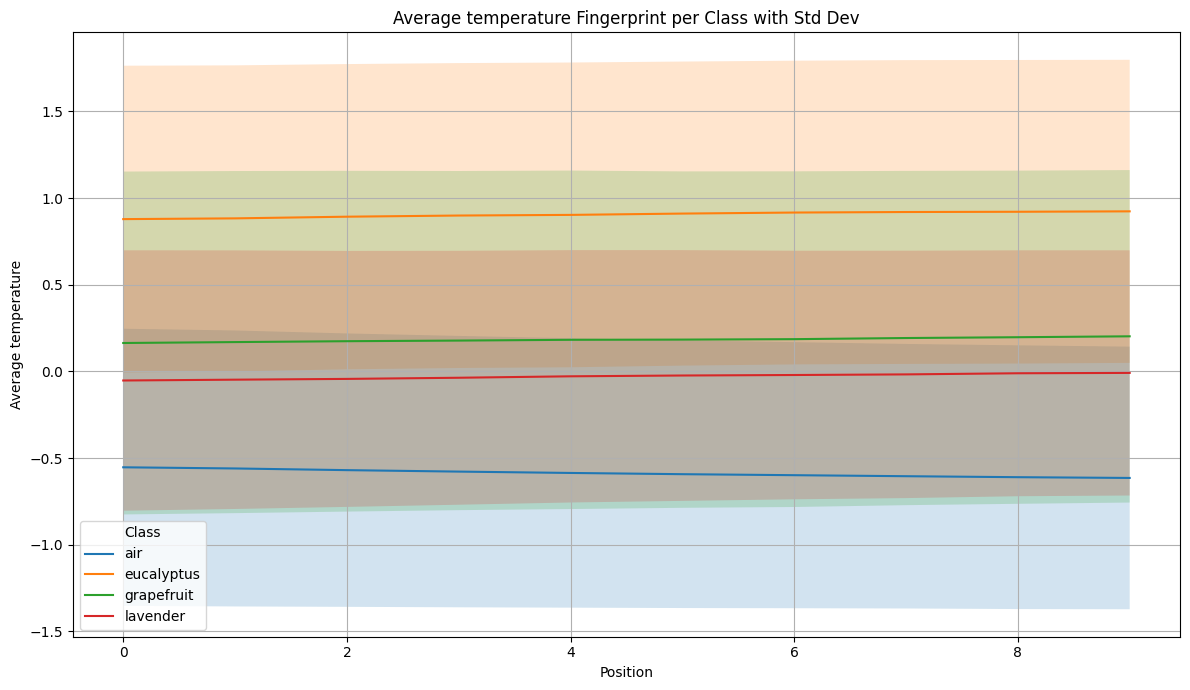

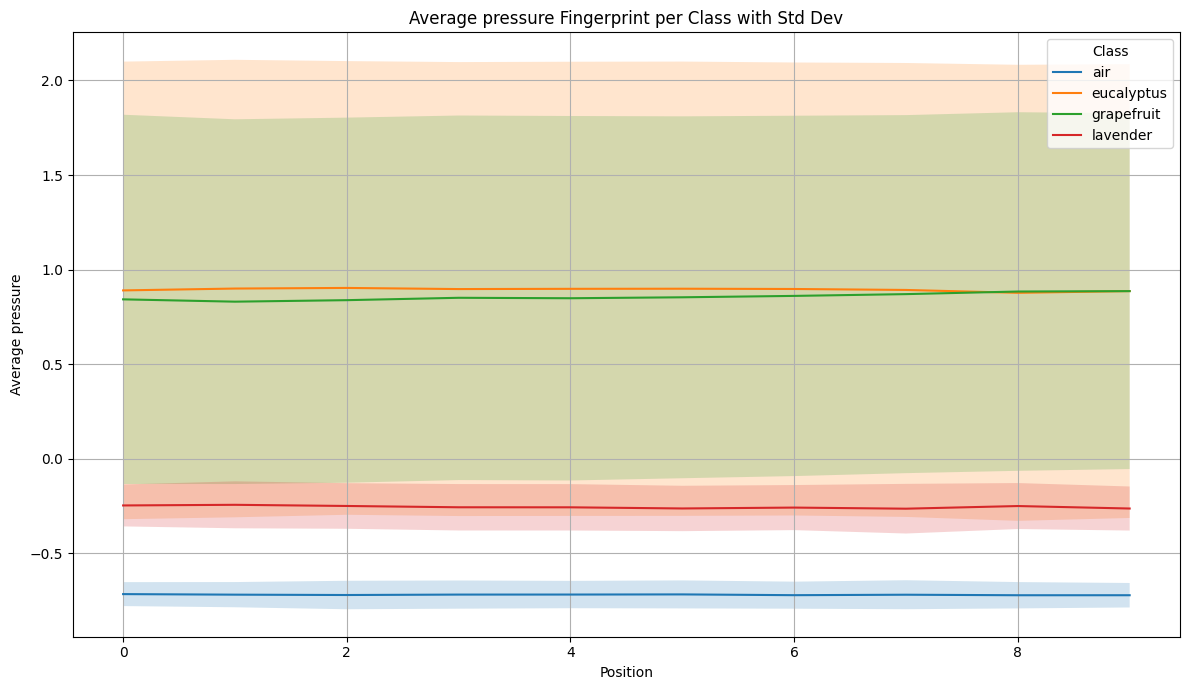

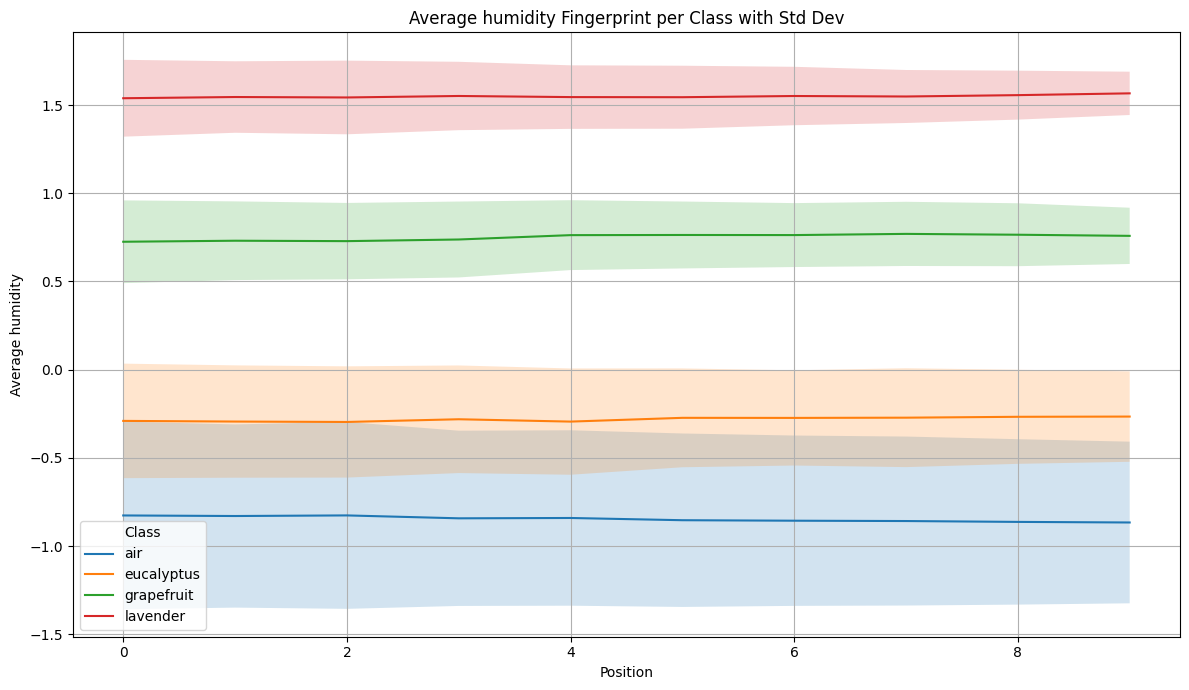

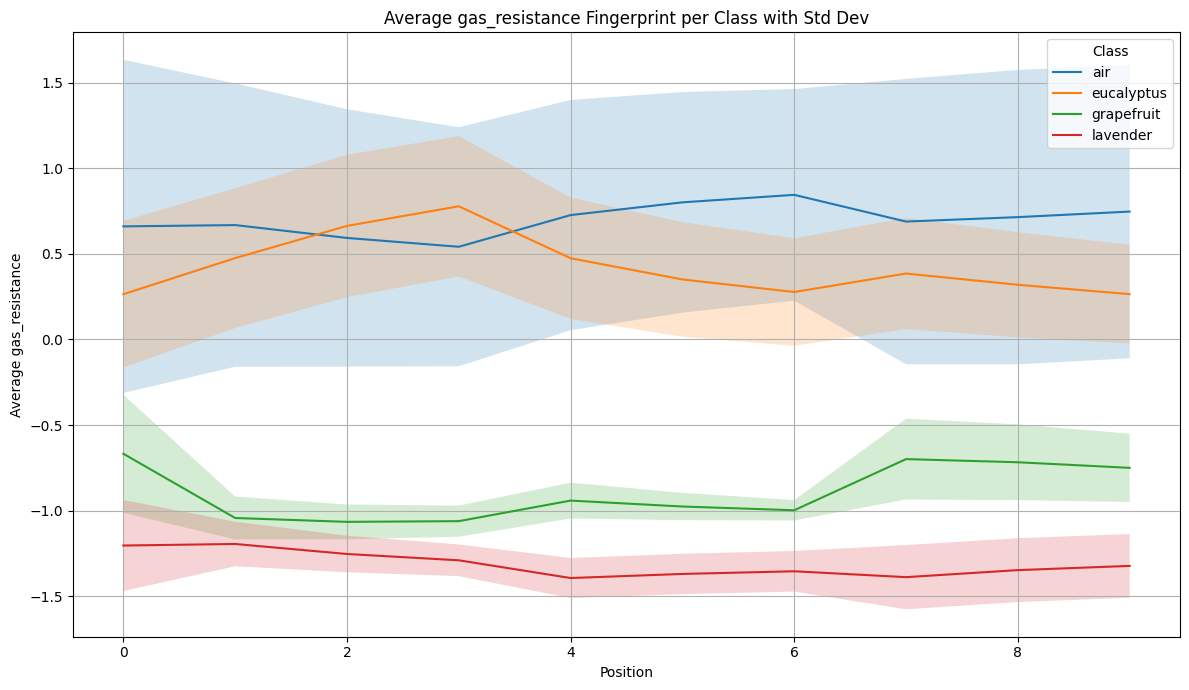

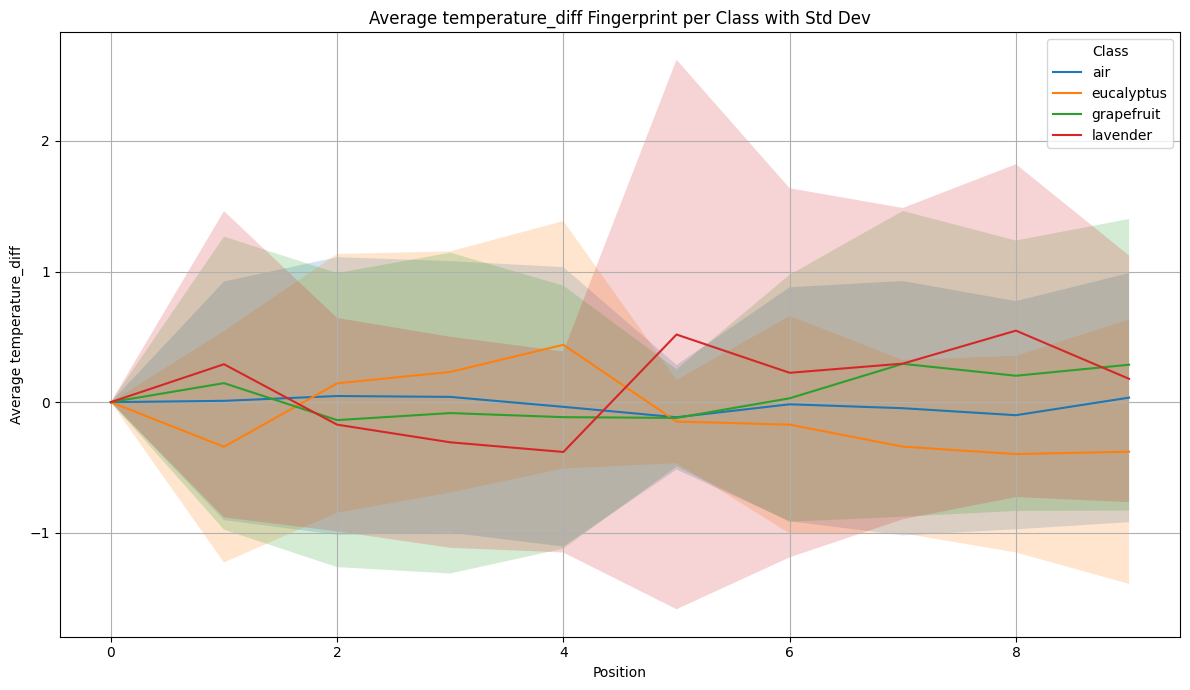

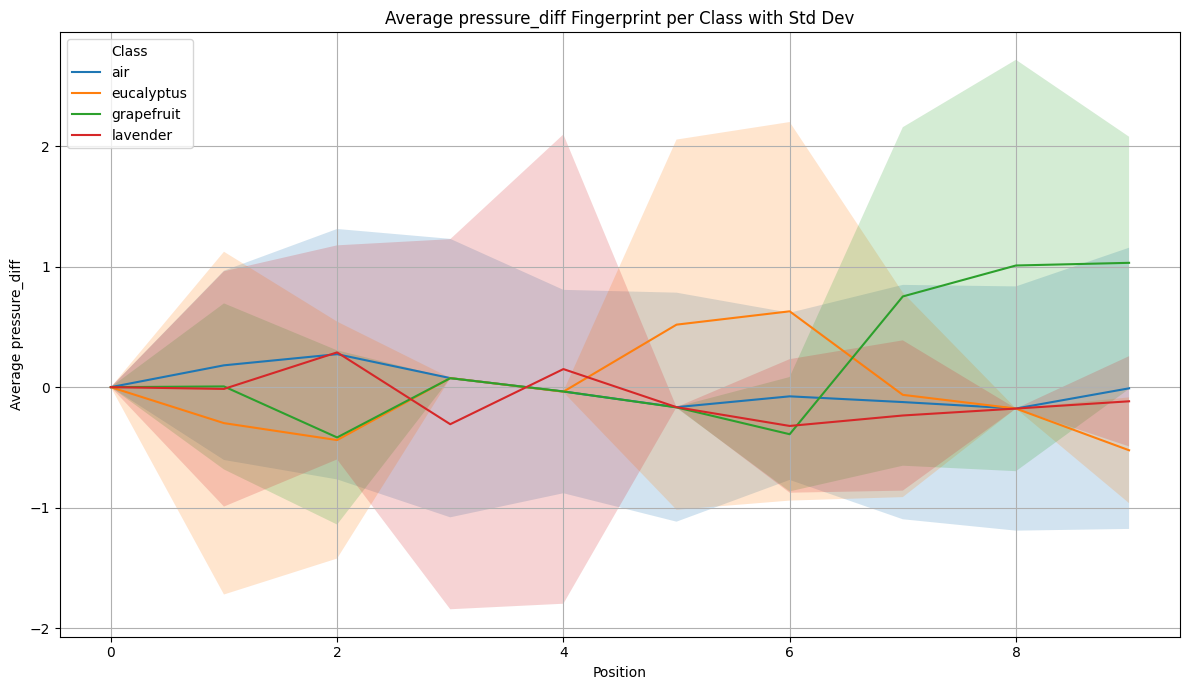

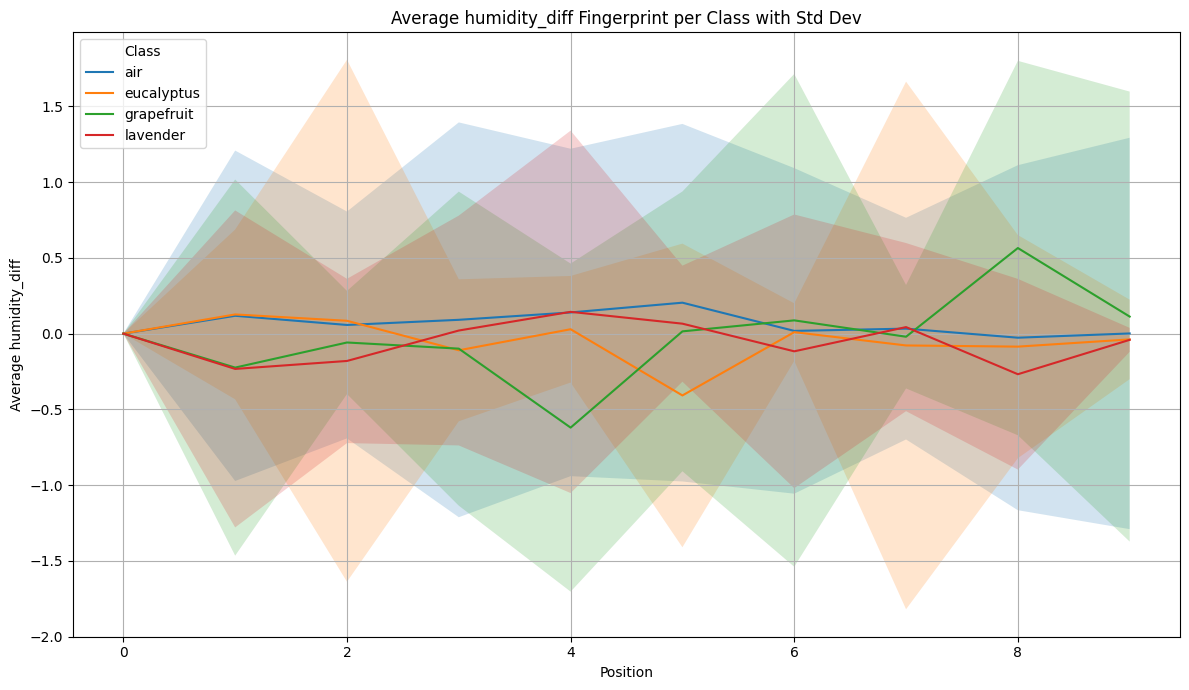

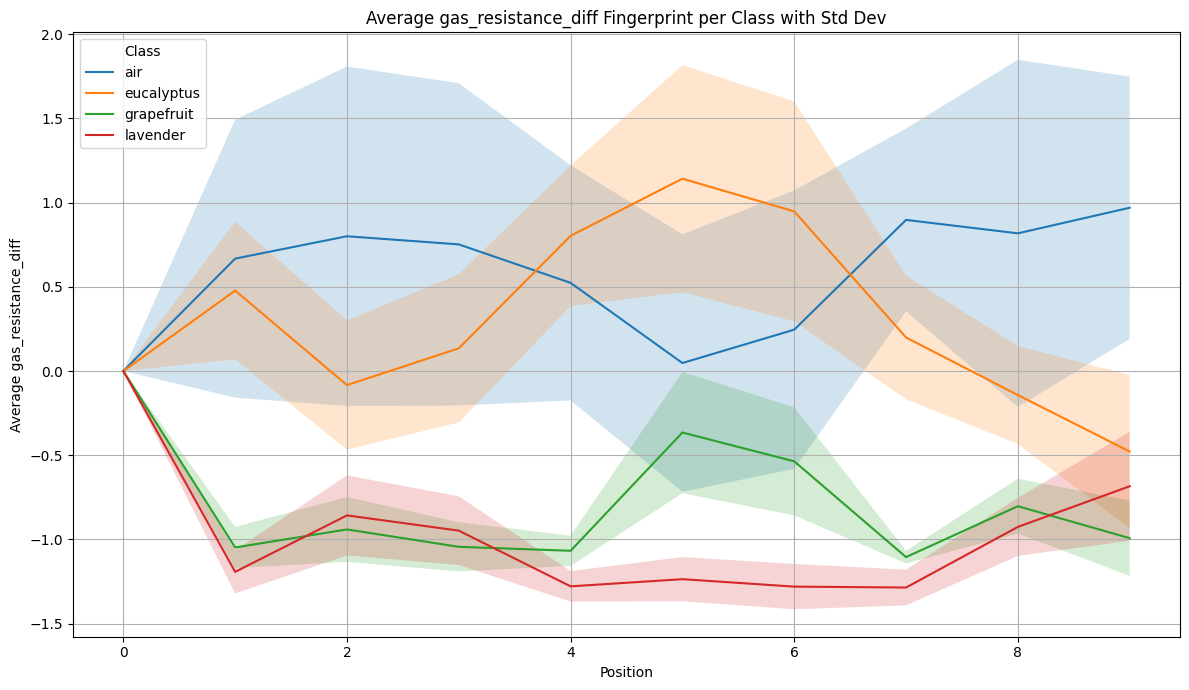

In [316]:
import matplotlib.pyplot as plt

def plot_fingerprint_stats(df: pd.DataFrame,
                            feature_cols: list[str],
                            target_col: str = "label",
                            pos_col: str = "position"):
    for feat in feature_cols:

        stats = (
            df.groupby([target_col, pos_col])[feat]
                .agg(["mean", "std"])
                .reset_index()
        )
        stats.rename(
            columns={"mean": f"avg_{feat}", "std": f"std_{feat}"},
            inplace=True,
        )

        classes = stats[target_col].unique()
        plt.figure(figsize=(12, 7))

        for cls in classes:
            cls_df = stats[stats[target_col] == cls]
            x = cls_df[pos_col]
            y = cls_df[f"avg_{feat}"]
            ystd = cls_df[f"std_{feat}"]

            plt.plot(x, y, label=cls)
            plt.fill_between(x, y - ystd, y + ystd, alpha=0.2)

        plt.xlabel(pos_col.capitalize())
        plt.ylabel(f"Average {feat}")
        plt.title(f"Average {feat} Fingerprint per Class with Std Dev")
        plt.legend(title="Class")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# call the helper with the training dataframe
plot_fingerprint_stats(train_data_scaled, FEATURE_COLS_EXTENDED)

### PCA

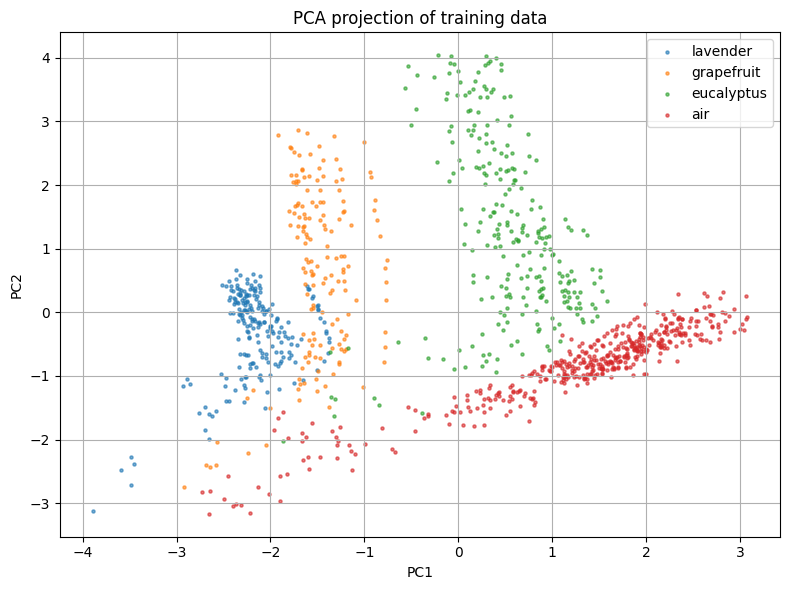

In [317]:
from sklearn.decomposition import PCA

def plot_pca(df: pd.DataFrame,
             feature_cols: list[str],
             target_col: str = TARGET_COL) -> tuple[PCA, np.ndarray]:
    """
    run PCA on the given dataframe (features are scaled) and scatter
    the first two principal components, colouring points by `target_col`.

    returns the fitted PCA instance and the 2‑d transformed array.
    """
    pca = PCA(n_components=2, random_state=SEED)
    components = pca.fit_transform(df[feature_cols])

    plt.figure(figsize=(8, 6))
    for cls in df[target_col].unique():
        mask = df[target_col] == cls
        plt.scatter(components[mask, 0],
                    components[mask, 1],
                    label=cls,
                    alpha=0.6, s=5)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA projection of training data")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pca, components

# apply to the training dataset
pca_model, X_train_pca = plot_pca(train_data_scaled, FEATURE_COLS_EXTENDED)

In [286]:
train_data.describe()

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,humidity_diff,gas_resistance_diff
count,880.0,880.000000,880.000000,880.000000,880.0,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,3.0,18.738636,4.500000,218.000000,150.0,30.279148,1035.370455,0.018036,-0.127553,-0.380069,-0.104557
std,0.0,10.679416,2.873915,91.899931,0.0,0.684832,0.538941,0.027569,0.274288,10.264595,0.355576
min,3.0,1.000000,0.000000,100.000000,150.0,28.030000,1034.440000,-0.033877,-0.924773,-122.390449,-1.201326
25%,3.0,11.750000,2.000000,100.000000,150.0,29.877500,1035.120000,-0.003357,-0.263101,-2.012668,-0.343378
50%,3.0,17.000000,4.500000,200.000000,150.0,30.280000,1035.230000,0.014006,-0.052619,-0.180467,-0.020141
75%,3.0,24.000000,7.000000,320.000000,150.0,30.730000,1035.660000,0.032208,0.080886,1.117588,0.108209
max,3.0,44.000000,9.000000,320.000000,150.0,31.850000,1036.800000,0.072592,0.341426,143.733742,1.024261


In [287]:
USE_PCA = True

if USE_PCA:
    for i in range(pca_model.components_.shape[0]):
        train_data[f"pca_{i}"] = X_train_pca[:, i]

In [288]:
pca_model.components_

array([[-0.59090972,  0.60292234,  0.0732909 ,  0.5309791 ],
       [ 0.04042752, -0.03846802,  0.99723968, -0.04897809]])

In [289]:
NUM_PCA_COMPONENTS = pca_model.components_.shape[0]
PCA_FEAT = [f"pca_{i}" for i in range(NUM_PCA_COMPONENTS)]

In [290]:
tmp = np.matmul(train_data_scaled[FEATURE_COLS_EXTENDED].to_numpy() - pca_model.mean_, pca_model.components_.T)
np.allclose(tmp, pca_model.transform(train_data_scaled[FEATURE_COLS_EXTENDED].to_numpy()))

c:\Users\Benedek\!_Extr\Expo\repo\AIExpo\.env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


True

### Export Train Data

In [291]:
model_dir = os.path.join(SAVE_PATH, MODEL_NAME)
if not os.path.isdir(model_dir): os.mkdir(model_dir)
train_data.to_csv(os.path.join(model_dir, "train_data.csv"))

### Create Sequences

In [292]:
import numpy as np

def create_sequences_grouped(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    seq_len: int
):
    X, y = [], []
    grouped = df.groupby("id")
    num_skipped = 0
    for _id, group in grouped:
        group = group.sort_values("position")
        data = group[feature_cols].values

        if len(data) == seq_len:
            X.append(data)
            y.append(int(group[target_col].iloc[0]))
        else:
            num_skipped += 1
    print("Number of sequences skipped: ", num_skipped)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


# X_train_seq, y_train_seq = create_sequences_grouped(train_data, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)
# X_test_seq, y_test_seq = create_sequences_grouped(test_data, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)


X_train_seq, y_train_seq = create_sequences_grouped(train_data_scaled, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)
# X_test_seq, y_test_seq = create_sequences_grouped(test_data, PCA_FEAT, 'label_enc', SEQ_LEN)

Number of sequences skipped:  0


In [293]:
train_data_scaled

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,humidity_diff,gas_resistance_diff,label_enc
10792,3,12,0,320,150,30.30,1035.40,1.876311,-1.197226,grapefruit,3_3_12,0.000000,0.000000,2
10888,3,13,0,320,150,30.38,1035.44,1.828404,-1.199381,grapefruit,3_3_13,0.000000,0.000000,2
10989,3,14,0,320,150,30.45,1035.46,1.764528,-1.212049,grapefruit,3_3_14,0.000000,0.000000,2
11184,3,16,0,320,150,30.58,1035.54,1.796466,-1.251434,grapefruit,3_3_16,0.000000,0.000000,2
11279,3,17,0,320,150,30.64,1035.60,1.772512,-1.277719,grapefruit,3_3_17,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,3,2,9,320,150,28.65,1035.14,0.794275,-1.624348,air,0_3_2,-0.200362,0.023496,0
2019,3,20,9,320,150,29.97,1035.17,-1.399960,1.417689,air,0_3_20,0.221526,1.023304,0
2120,3,21,9,320,150,30.01,1035.17,-1.424341,1.452777,air,0_3_21,-0.200362,1.016989,0
2605,3,26,9,320,150,30.20,1035.19,-1.700652,1.661294,air,0_3_26,0.040717,1.346399,0


## Build model

In [294]:
pca_model.n_components

2

In [297]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D

pca_layer = Dense(pca_model.n_components, use_bias=True, activation=None, trainable=False)
pca_layer.build(input_shape=[len(FEATURE_COLS_EXTENDED)])
pca_layer.set_weights([pca_model.components_.T, -(np.matmul(pca_model.mean_, pca_model.components_.T))])

model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED))),

    pca_layer,

    Conv1D(8, kernel_size=2, activation='relu'),
    Conv1D(8, kernel_size=2, activation='relu'),

    GlobalAveragePooling1D(),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 10, 2)          │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 9, 8)           │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 8, 8)           │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398 (1.55 KB)

 Trainable params: 388 (1.52 KB)

 Non-trainable params: 10 (40.00 B)

## Train model

In [298]:
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.1,
    stratify=y_train_seq,
    random_state=42
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.2254 - loss: 1.3358 - val_accuracy: 0.1250 - val_loss: 1.3389
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2817 - loss: 1.3023 - val_accuracy: 0.1250 - val_loss: 1.3278
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3380 - loss: 1.3157 - val_accuracy: 0.1250 - val_loss: 1.3170
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2817 - loss: 1.2839 - val_accuracy: 0.1250 - val_loss: 1.3065
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3521 - loss: 1.2730 - val_accuracy: 0.2500 - val_loss: 1.2964
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4507 - loss: 1.2697 - val_accuracy: 0.2500 - val_loss: 1.2865
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4366 - loss: 1.2435 - val_accuracy: 0.2500 - val_loss: 1.2767
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5352 - loss: 1.2276 - val_accuracy: 0.3750 - val_loss

### Save Model

In [299]:
MODEL_NAME

'background_pca_2'

In [300]:
model_dir = os.path.join(SAVE_PATH, MODEL_NAME)
if not os.path.isdir(model_dir): os.mkdir(model_dir)
model.save(os.path.join(SAVE_PATH, MODEL_NAME, "model.keras"))

## Evaluate model

In [75]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Overall Test Accuracy: 0.5844155844155844
air                  : 0.805  (n_test=41)
eucalyptus           : 0.273  (n_test=33)
grapefruit           : 0.895  (n_test=19)

Classification Report (only shows classes present in y_test):
              precision    recall  f1-score   support

         air       0.56      0.79      0.65        42
  eucalyptus       0.64      0.26      0.37        35
  grapefruit       0.52      0.52      0.52        33
    lavender       0.65      0.70      0.67        44

    accuracy                           0.58       154
   macro avg       0.59      0.57      0.55       154
weighted avg       0.59      0.58      0.56       154



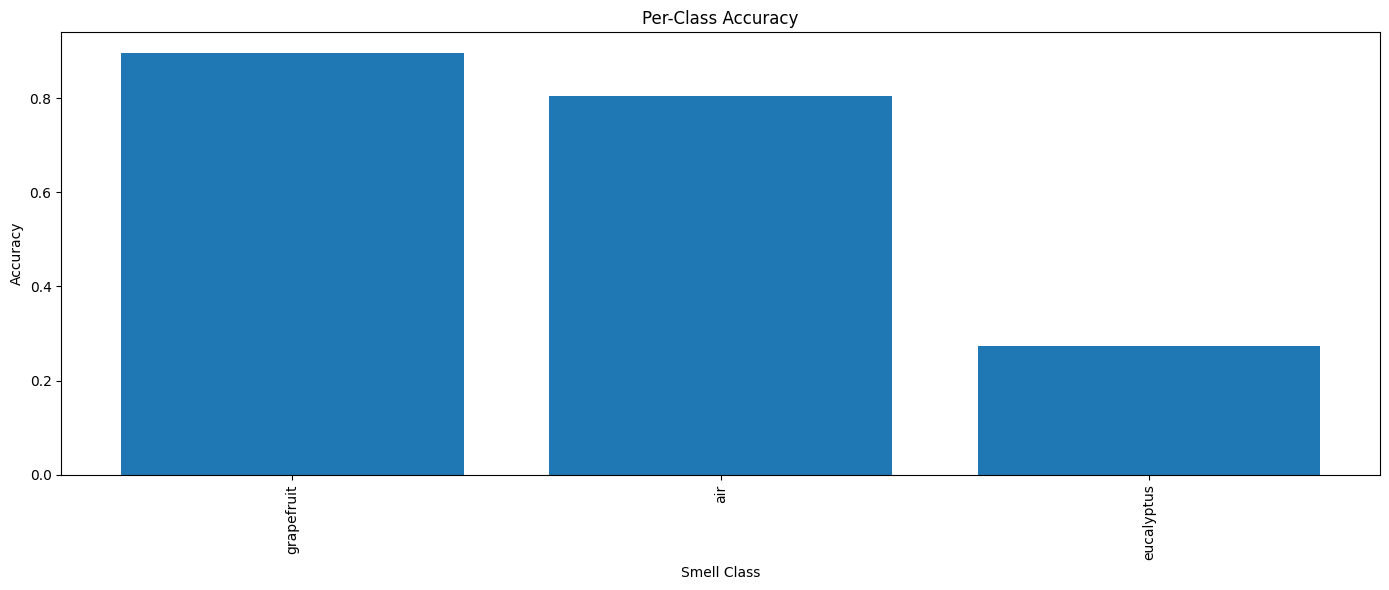

In [76]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()